In [3]:
#download the data
import os
import pandas as pd

data_path = "../data/train"

reviews = []
sentiments = []

In [4]:
#load positive reviews
pos_path = os.path.join(data_path, "pos")

for file in os.listdir(pos_path):

    with open(os.path.join(pos_path, file), encoding="utf-8") as f:
        reviews.append(f.read())
        sentiments.append(1)

In [5]:
#loading negative reviews 
neg_path = os.path.join(data_path, "neg")

for file in os.listdir(neg_path):

    with open(os.path.join(neg_path, file), encoding="utf-8") as f:
        reviews.append(f.read())
        sentiments.append(0)

In [6]:
#create dataframe 
df = pd.DataFrame({
    "review": reviews,
    "sentiment": sentiments
})

df.head()

,review,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


In [7]:
#shape of data 
df.shape

(25000, 2)

In [8]:

#train-test split 
#We split BEFORE vectorization.Why? To avoid: DATA LEAKAGE
from sklearn.model_selection import train_test_split

X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(20000,)
(5000,)


In [9]:
#So we need to convert text → numbers.That’s exactly what this TF-IDF cell does.
#Term Frequency - Inverse Document Frequency
#But words like: "love" "terrible" are VERY useful. TF-IDF tries to capture exactly this.
#fit() The vectorizer LEARNS vocabulary from training data. 
#transform(then converts reviews into numerical vectors 
#we do perform fit() only on train data as if we  perform  on test data it will be llater an unfair evaluation and this is called data leakage accuracy gets inflated 
#we perform only transform and not fit_transform on test data so that it remains unseen 
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [10]:
#applying model Logistic regression
#model.fit()--> train the model using  data -- learning  phase 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
#making  predictions
y_pred = model.predict(X_test_tfidf)

In [12]:
#accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8836


In [13]:
#full evaluation report 
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2485
           1       0.88      0.90      0.89      2515

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



In [14]:
#giving custom sentence to see the prediction
review = ["i slept  through whole movie "]

review_tfidf = tfidf.transform(review)

prediction = model.predict(review_tfidf)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Negative Review


In [15]:
import pickle

# save model
with open("../model/sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

# save vectorizer
with open("../model/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


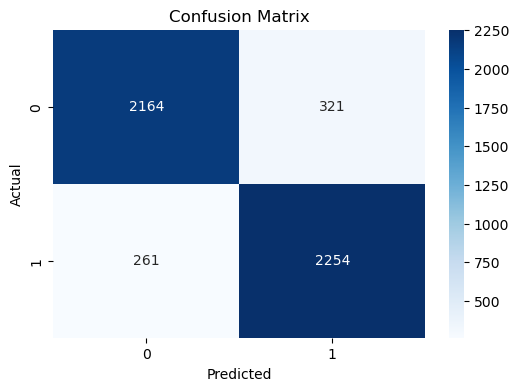

In [16]:
#seaborn is a python visualization library built on top of matplotib , it gives prettier easier statistical plots 
#sns.heatmap()--> automatically creates colored grids annotations and clean formatting 

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [17]:
#SVM MODEL 
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
svm_model= LinearSVC()
svm_model.fit(X_train_tfidf,y_train)
svm_pred=svm_model.predict(X_test_tfidf)
svm_accuracy=accuracy_score(y_test,svm_pred)
print("SVM Accuracy: ",svm_accuracy)


SVM Accuracy:  0.8708


In [18]:
### For TF-IDF text classification:

#Logistic Regression is often extremely strong
#especially on balanced datasets like IMDb

#SVM is also strong, but:

#default hyperparameters may not be optimal
#LinearSVC sometimes needs tuning
#dataset characteristics matter

#This is EXACTLY what real ML experimentation looks like.###

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8452


In [20]:
#LSTM → sequence learning unnnlike if-idf
#Meaning: word order matters context matters
from tensorflow.keras.preprocessing.text import Tokenizer ##converts words to integers 
from tensorflow.keras.preprocessing.sequence import pad_sequences #makes all reviews same length

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

#embedding- learns word representatives
#lstm- sequence learning 
#dense- final  prediction layer 

In [ ]:
#tokenizer converts words->integer ids eg "movie"->15 etc 
#then a review becomes[15,30,102]

max_words=5000 #common words  =5000 or less
tokenizer=Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train) #learns vocabulary from training reviews 
X_train_seq = tokenizer.texts_to_sequences(X_train)  #converts reviews into number sequences
X_test_seq=tokenizer.texts_to_sequences(X_test)



In [ ]:
#padding  since reviews have different lengths we need padding as NN works  on fixed size input 
max_length=200
X_train_pad=pad_sequences(X_train_seq,maxlen=max_length)
X_test_pad=pad_sequences(X_test_seq,maxlen=max_length)

#every review becomes of 200 length shorter ma  zeroes add hote hai and  longer reviews get truncated 

In [ ]:
model_lstm=Sequential()

model_lstm.add(Embedding(input_dim=5000,output_dim=64)) #converts  word ids into dense  vector these vectors capture  meaning relationships 
#input dim=5000 that is vocabulary size and  output dim=64 so each word  becomes 64-dimensional vector 
model_lstm.add(LSTM(64))   #it is the sequence learning brain it reads review word by word and  remembers context 
model_lstm.add(Dense(1,activation='sigmoid')) #final prediction layer outputs probability 0 and 1, 0 for positive and 1 for negative sigmoid gives value between 0 and 1 



In [27]:
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=3, #one eppoch means model sees entire  training dataset once 3 because it is faster,avoids huge training time
    batch_size=64, #instead of learning from all 20k reviews at once, model trains in small groups of 64  reviews (MINI_BATCH TRAINING)
    validation_split=0.2  #tensorflow automatically  keeps 20% training data for validation . this helps detect overfitting,generalization
)

Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7447 - loss: 0.4980 - val_accuracy: 0.8422 - val_loss: 0.3825
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.8776 - loss: 0.3025 - val_accuracy: 0.8173 - val_loss: 0.4115
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - accuracy: 0.9111 - loss: 0.2352 - val_accuracy: 0.8630 - val_loss: 0.3592


In [29]:
test_loss, test_accuracy = model_lstm.evaluate(
    X_test_pad,
    y_test
)

print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8688 - loss: 0.3529
Test Accuracy: 0.8687999844551086


In [30]:
model_lstm.save("../model/lstm_sentiment_model.h5")

print("LSTM model saved successfully!")

LSTM model saved successfully!


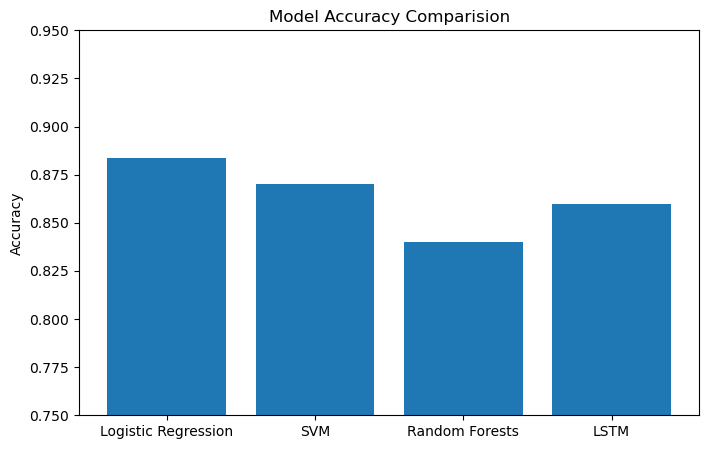

In [32]:
import matplotlib.pyplot as plt

models=[
    "Logistic Regression",
    "SVM",
    "Random Forests",
    "LSTM"
] 
accuracies=[0.8836,0.8702,0.84,0.86]
plt.figure(figsize=(8,5))
plt.bar(models,accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparision")
plt.ylim(0.75,0.95)
plt.show()

2026-06-05 00:44:19.287 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-05 00:44:19.465 
  command:

    streamlit run c:\Users\Dhriti\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-05 00:44:19.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-05 00:44:19.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-05 00:44:19.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-05 00:44:19.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-05 00:44:19.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-05 00:44:19.471 Thread 'MainThread': m